In [73]:
import numpy as np
import matplotlib.pyplot as plt

import legume
from legume import GuidedModeExp, Circle, Ring, ShapesLayer

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Define W1 waveguide with a supercell

In [74]:
# PhC parameters
a_nm = 250            # lattice constant in nm — change this to rescale the simulation
D = 170 / a_nm          # slab thickness in units of a (always 170 nm physical)
ra = 75 / a_nm           # hole radius in units of a
n_slab = 3.46
eps_b = n_slab**2       # background permittivity
eps_c = 1               # hole permittivity (air)
eps_lower, eps_upper = 1, 1  # cladding permittivities

# supercell parameters
Ny = 12      # Number of rows in the y-direction
Nx = 4       # Supercell size in the x-direction
if (Ny%2 != 0): raise ValueError('number of rows Ny must be even')
Nholes = Nx*(Ny-1)    # total number of holes

# Initialize a rectangular lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

In [75]:
def build_w1_waveguide():
    """Build the standard W1 photonic crystal waveguide supercell.
    The structure is symmetric wrt a xz mirror plane,
    which allows disentangling modes with different kz-symmetry.
    """
    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D, eps_b=eps_b)

    xc = []; yc = []; rc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            rc.append(ra)
            jhole += 1
            # upper edge row is half-holes; skip the lower symmetric copy to avoid double counting
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                rc.append(ra)
                jhole += 1

    for n in range(jhole):
        phc.layers[-1].add_shape(legume.Circle(eps=eps_c, r=rc[n], x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

Nholes, Nholes_check = 44 44
npw = 697


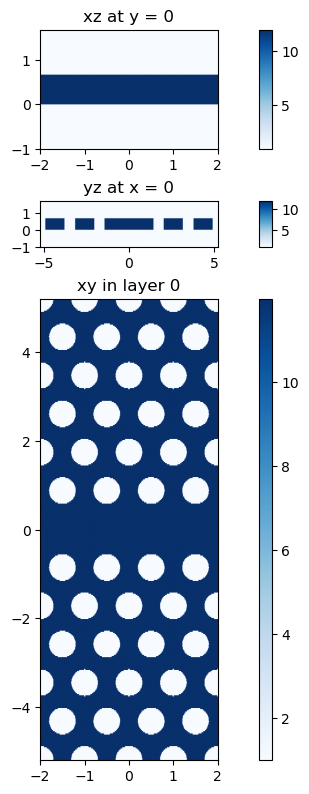

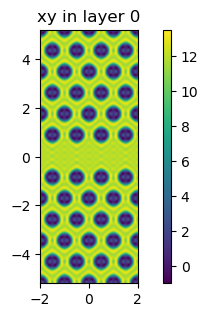

In [76]:
# Initialize the photonic crystal
phc0, Nholes_check = build_w1_waveguide()
print('Nholes, Nholes_check =', Nholes, Nholes_check)

# Visualize the structure
legume.viz.structure(phc0, xz=True, yz=True, figsize=3, cmap='Blues', Nx=400, Ny=400, Nz=200)

gmax = 2
truncate_g = 'tbt'
gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
npw = np.shape(gme0.gvec)[1]
print('npw =', npw)

legume.viz.eps_ft(gme0, Nx=400, Ny=400, figsize=2, cbar=True, cmap='viridis')

In [77]:
kz_symmetry = 'odd'

# Define a BZ path in kx and run the GME
# we reduce the number of k-points, to reduce the computing time later
nintervals = 30
nk = nintervals +1
path = lattice.bz_path([[0, 0], np.array([np.pi/Nx, 0])], [nintervals])

kpoints = path['kpoints']
#print(kpoints)

# change of basis for symmetrization can be done with dense or sparse matrices
# in this example with a low number of plane waves they are almost equivalent
# sparse matrices have a more favourable scaling with the number of plane waves
# symmetrization + sparse matrices + autograd is the newest feature of the code, still in beta-testing
use_sparse = True

# we consider only xy-even (TE-like) modes: this is the only polarization yielding a photonic band gap
gmode_inds, numeig = [0], 50

gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
gme0.run(kpoints=path['kpoints'],
        gmode_inds=gmode_inds,
        numeig=numeig,
        verbose=True,
        compute_im=False,
        eig_sigma = 0.0,
        use_sparse=use_sparse,
        kz_symmetry=kz_symmetry, angles=path['angles']
        )

freqs = gme0.freqs
nfreq = np.shape(freqs)[1]
print(freqs.shape)


12.467s total time for real part of frequencies in GuidedModeExp, of which
  3.943s (32%) for guided modes computation using the gmode_compute='exact' method
  0.015s (0%) for inverse matrix of Fourier-space permittivity
  3.994s (32%) for matrix diagionalization using the 'eigh' solver
  4.055s (33%) for creating GME matrix
  0.420s (3%) for creating change of basis matrix and multiply it using sparse matrices
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
(31, 50)


<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_276075/1569531143.py:6: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$a k_x/ \pi$')


Text(0, 0.5, 'Frequency')

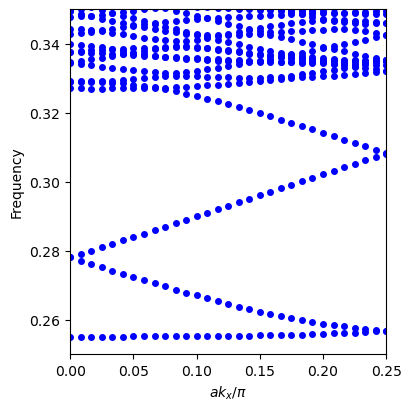

In [78]:
# Plot the (folded) waveguide bands
fig, ax = plt.subplots(1, constrained_layout=True, figsize=(4, 4))
ax.plot(kpoints[0, :]/np.pi, freqs, 'bo', markersize=4)
ax.set_ylim([0.25, 0.35])
ax.set_xlim([0, kpoints[0, -1]/np.pi])
ax.set_xlabel('$a k_x/ \pi$')
ax.set_ylabel('Frequency')

In [79]:
# ---- Select waveguide band (inspect plot above) ----
b_target = 29       # Index of the waveguide defect band

# ---- Extract waveguide band ----
kx = path['kpoints'][0, :]
wg_band = freqs[:, b_target]

# ---- Waveguide band metrics ----
wg_freq_min, wg_freq_max = wg_band.min(), wg_band.max()
wg_bandwidth = wg_freq_max - wg_freq_min
wg_center = (wg_freq_max + wg_freq_min) / 2

# ---- Band edge wavelength ----
f_edge = wg_band[-1]                        # normalized freq at BZ edge
lambda_edge_nm = a_nm / f_edge              # band edge wavelength in nm
lambda_edge_um = lambda_edge_nm / 1000      # band edge wavelength in µm

# ---- Group velocity: v_g = dω/dk (finite differences) ----
dk = np.diff(kx)
domega = np.diff(wg_band)
vg = domega / dk
kx_vg = (kx[:-1] + kx[1:]) / 2
ng = 1.0 / np.abs(vg)

# ---- Print summary ----
print("=" * 50)
print("BAND STRUCTURE METRICS")
print("=" * 50)
print(f"\nWaveguide Band (index {b_target}):")
print(f"  Freq min:          {wg_freq_min:.4f}")
print(f"  Freq max:          {wg_freq_max:.4f}")
print(f"  Bandwidth:         {wg_bandwidth:.4f}")
print(f"  Center frequency:  {wg_center:.4f}")
print(f"\nBand Edge:")
print(f"  f_edge (norm):     {f_edge:.4f}")
print(f"  lambda_edge:       {lambda_edge_nm:.1f} nm  ({lambda_edge_um:.4f} µm)")
print(f"\nGroup Velocity / Index:")
print(f"  v_g range:         [{vg.min():.4f}, {vg.max():.4f}]")
print(f"  n_g range:         [{ng.min():.2f}, {ng.max():.2f}]")
print(f"  n_g at zone edge:  {ng[-1]:.2f}")
print("=" * 50)

BAND STRUCTURE METRICS

Waveguide Band (index 29):
  Freq min:          0.2569
  Freq max:          0.2781
  Bandwidth:         0.0212
  Center frequency:  0.2675

Band Edge:
  f_edge (norm):     0.2569
  lambda_edge:       973.2 nm  (0.9732 µm)

Group Velocity / Index:
  v_g range:         [-0.0369, -0.0094]
  n_g range:         [27.06, 106.47]
  n_g at zone edge:  106.47


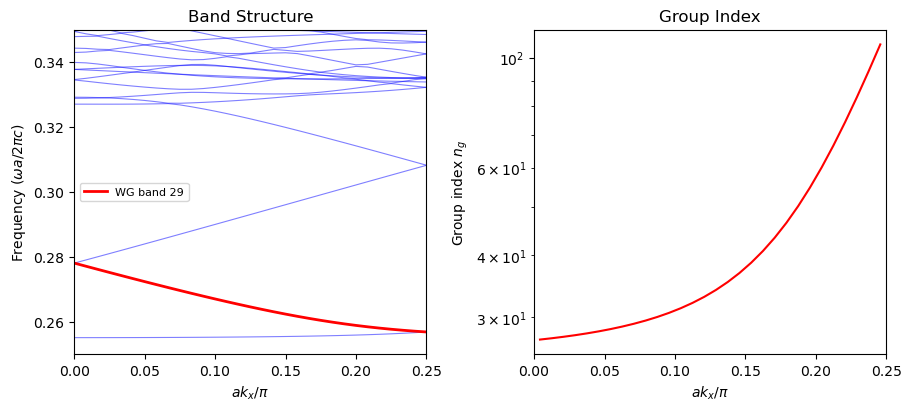

In [80]:
# ---- Band structure + group index plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(9, 4))

kx_norm = kx / np.pi
ax1.plot(kx_norm, freqs, 'b-', linewidth=0.8, alpha=0.5)
ax1.plot(kx_norm, wg_band, 'r-', linewidth=2, label=f'WG band {b_target}')
ax1.set_ylim([0.25, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure')
ax1.legend(fontsize=8)

ax2.plot(kx_vg / np.pi, ng, 'r-', linewidth=1.5)
ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index')
ax2.set_yscale('log')

plt.show()

## Oxidized-hole W1 waveguide
Each air hole gets a thin oxide layer on its inner wall.  
Structure (radially outward): **air core** → **oxide ring** → **silicon**

eps_ft for t_ox = 0.150 (oxide rings should be visible)


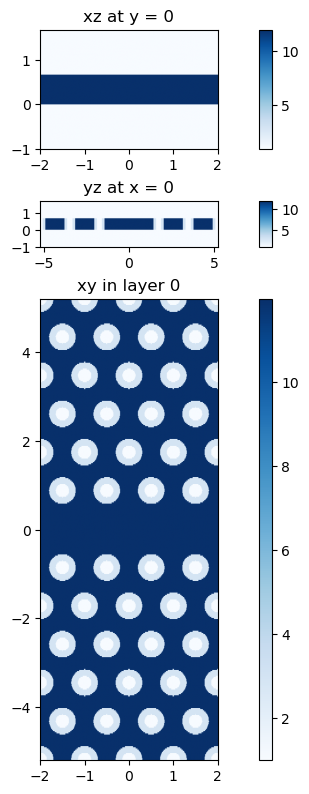

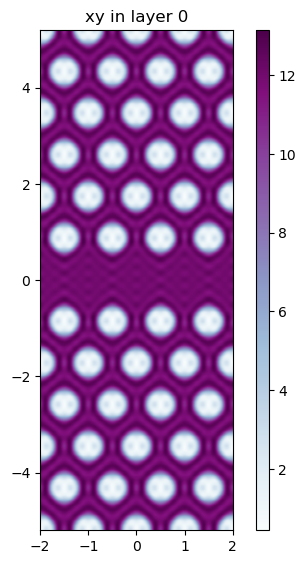

In [81]:
# Oxide parameters
n_oxide = 1.72
eps_oxide = n_oxide**2                         # Oxide permittivity                         
t_ox_values = np.linspace(0.01, 0.15, 8) # oxide thicknesses to sweep (in units of a)

def build_w1_waveguide_oxidized(t_ox):
    """Build a W1 waveguide where each hole has a thin oxide shell of thickness t_ox.
    Each hole is modeled as:
      - Ring(eps=eps_oxide, r_i=ra-t_ox, r_o=ra)  → oxide shell
      - Circle(eps=eps_c, r=ra-t_ox)               → air core
    These don't overlap, so legume's additive FT gives correct permittivity.
    """
    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D, eps_b=eps_b)

    r_air = ra - t_ox

    xc = []; yc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            jhole += 1
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                jhole += 1

    for n in range(jhole):
        phc.layers[-1].add_shape(Ring(eps=eps_oxide, r_i=r_air, r_o=ra,
                                      x_cent=xc[n], y_cent=yc[n]))
        phc.layers[-1].add_shape(Circle(eps=eps_c, r=r_air,
                                        x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

# Sanity-check visualization for the first thickness
phc_check, _ = build_w1_waveguide_oxidized(t_ox_values[-1])
gme_check = legume.GuidedModeExp(phc_check, gmax=gmax, truncate_g=truncate_g)
print(f"eps_ft for t_ox = {t_ox_values[-1]:.3f} (oxide rings should be visible)")
# Visualize the structure
legume.viz.structure(phc_check, xz=True, yz=True, figsize=3, cmap='Blues', Nx=400, Ny=400, Nz=200)
legume.viz.eps_ft(gme_check, Nx=400, Ny=400, figsize=3, cbar=True, cmap='BuPu')

In [82]:
# ---- Sweep over oxide thicknesses ----
b_target_ox = 29   # waveguide band index (adjust if needed)

results_ox = []

for t_ox in t_ox_values:
    print(f"\n--- t_ox = {t_ox:.3f}a ---")
    phc_ox, _ = build_w1_waveguide_oxidized(t_ox)
    gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
    gme_ox.run(kpoints=path['kpoints'],
               gmode_inds=gmode_inds,
               numeig=numeig,
               verbose=False,
               compute_im=False,
               eig_sigma=0.0,
               use_sparse=use_sparse,
               kz_symmetry=kz_symmetry, angles=path['angles'])

    freqs_ox   = gme_ox.freqs
    kx_ox      = path['kpoints'][0, :]
    wg_band_ox = freqs_ox[:, b_target_ox]
    vg_ox      = np.diff(wg_band_ox) / np.diff(kx_ox)
    kx_vg_ox   = (kx_ox[:-1] + kx_ox[1:]) / 2
    ng_ox      = 1.0 / np.abs(vg_ox)

    f_min, f_max = wg_band_ox.min(), wg_band_ox.max()
    f_edge_ox = wg_band_ox[-1]
    lam_edge_nm = a_nm / f_edge_ox
    lam_edge_um = lam_edge_nm / 1000

    print(f"  WG freq:   [{f_min:.4f}, {f_max:.4f}]   bw = {f_max-f_min:.4f}")
    print(f"  Band edge: {lam_edge_um:.4f} µm ({lam_edge_nm:.1f} nm)")
    print(f"  n_g range: [{ng_ox.min():.2f}, {ng_ox.max():.2f}]")

    results_ox.append({
        't_ox':    t_ox,
        'freqs':   freqs_ox,
        'wg_band': wg_band_ox,
        'kx_vg':   kx_vg_ox,
        'ng':      ng_ox,
        'f_min':   f_min,
        'f_max':   f_max,
        'f_edge':  f_edge_ox,
        'lam_edge_nm': lam_edge_nm,
        'lam_edge_um': lam_edge_um,
        'bw':      f_max - f_min,
        'center':  (f_min + f_max) / 2,
        'ng_min':  ng_ox.min(),
        'ng_max':  ng_ox.max(),
        'ng_edge': ng_ox[-1],
    })

print("\nSweep complete.")


--- t_ox = 0.010a ---
  WG freq:   [0.2566, 0.2779]   bw = 0.0213
  Band edge: 0.9744 µm (974.4 nm)
  n_g range: [27.01, 104.24]

--- t_ox = 0.030a ---
  WG freq:   [0.2560, 0.2775]   bw = 0.0216
  Band edge: 0.9767 µm (976.7 nm)
  n_g range: [26.91, 100.72]

--- t_ox = 0.050a ---
  WG freq:   [0.2554, 0.2772]   bw = 0.0218
  Band edge: 0.9789 µm (978.9 nm)
  n_g range: [26.79, 98.19]

--- t_ox = 0.070a ---
  WG freq:   [0.2548, 0.2768]   bw = 0.0220
  Band edge: 0.9810 µm (981.0 nm)
  n_g range: [26.66, 96.40]

--- t_ox = 0.090a ---
  WG freq:   [0.2543, 0.2765]   bw = 0.0222
  Band edge: 0.9830 µm (983.0 nm)
  n_g range: [26.53, 95.19]

--- t_ox = 0.110a ---
  WG freq:   [0.2538, 0.2762]   bw = 0.0224
  Band edge: 0.9849 µm (984.9 nm)
  n_g range: [26.38, 94.40]

--- t_ox = 0.130a ---
  WG freq:   [0.2534, 0.2759]   bw = 0.0225
  Band edge: 0.9867 µm (986.7 nm)
  n_g range: [26.24, 93.91]

--- t_ox = 0.150a ---
  WG freq:   [0.2529, 0.2756]   bw = 0.0227
  Band edge: 0.9884 µm (988.

## Comparison: Original vs Oxidized

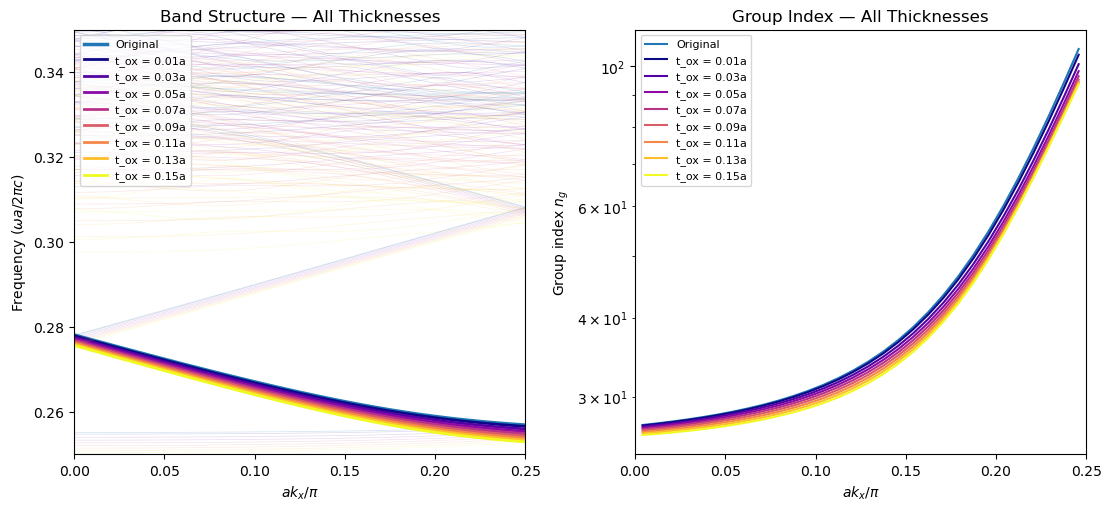

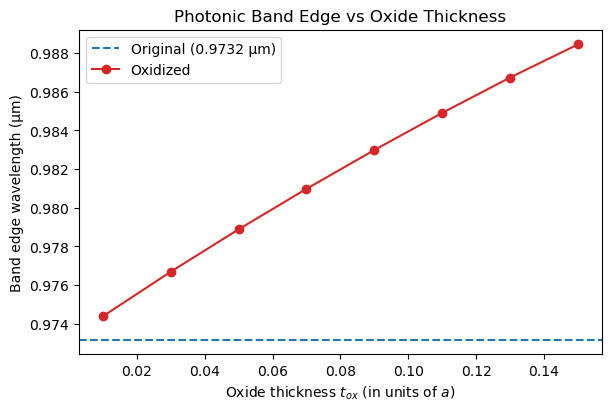

COMPARISON TABLE
      t_ox    f_edge      λ_edge     f_min     f_max        bw    ng_min   ng_edge
------------------------------------------------------------------------------------------
  original    0.2569     0.9732µm    0.2569    0.2781    0.0212     27.06    106.47
     0.010    0.2566     0.9744µm    0.2566    0.2779    0.0213     27.01    104.24
     0.030    0.2560     0.9767µm    0.2560    0.2775    0.0216     26.91    100.72
     0.050    0.2554     0.9789µm    0.2554    0.2772    0.0218     26.79     98.19
     0.070    0.2548     0.9810µm    0.2548    0.2768    0.0220     26.66     96.40
     0.090    0.2543     0.9830µm    0.2543    0.2765    0.0222     26.53     95.19
     0.110    0.2538     0.9849µm    0.2538    0.2762    0.0224     26.38     94.40
     0.130    0.2534     0.9867µm    0.2534    0.2759    0.0225     26.24     93.91
     0.150    0.2529     0.9884µm    0.2529    0.2756    0.0227     26.09     93.62


In [83]:
# ---- Overlay: original + all oxidized thicknesses ----
cmap = plt.cm.plasma
colors = [cmap(i / max(len(results_ox) - 1, 1)) for i in range(len(results_ox))]

kx_norm = kx / np.pi
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(11, 5))

# --- Band structures ---
ax1.plot(kx_norm, freqs, '-', color='tab:blue', linewidth=0.5, alpha=0.2)
ax1.plot(kx_norm, wg_band, '-', color='tab:blue', linewidth=2.5, label='Original')

for r, c in zip(results_ox, colors):
    ax1.plot(kx_norm, r['freqs'], '-', color=c, linewidth=0.5, alpha=0.15)
    ax1.plot(kx_norm, r['wg_band'], '-', color=c, linewidth=2,
             label=f"t_ox = {r['t_ox']:.2f}a")

ax1.set_ylim([0.25, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure — All Thicknesses')
ax1.legend(fontsize=8, loc='upper left')

# --- Group index ---
ax2.plot(kx_vg / np.pi, ng, '-', color='tab:blue', linewidth=1.5, label='Original')
for r, c in zip(results_ox, colors):
    ax2.plot(r['kx_vg'] / np.pi, r['ng'], '-', color=c, linewidth=1.5,
             label=f"t_ox = {r['t_ox']:.2f}a")

ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index — All Thicknesses')
ax2.set_yscale('log')
ax2.legend(fontsize=8)

plt.show()

# ---- Band edge wavelength vs oxide thickness plot ----
fig2, ax3 = plt.subplots(1, 1, constrained_layout=True, figsize=(6, 4))
t_ox_arr = [r['t_ox'] for r in results_ox]
lam_arr  = [r['lam_edge_um'] for r in results_ox]
ax3.axhline(lambda_edge_um, color='tab:blue', linestyle='--', label=f'Original ({lambda_edge_um:.4f} µm)')
ax3.plot(t_ox_arr, lam_arr, 'o-', color='tab:red', markersize=6, label='Oxidized')
ax3.set_xlabel(r'Oxide thickness $t_{ox}$ (in units of $a$)')
ax3.set_ylabel(r'Band edge wavelength (µm)')
ax3.set_title('Photonic Band Edge vs Oxide Thickness')
ax3.legend()
plt.show()

# ---- Metrics table ----
print("=" * 90)
print("COMPARISON TABLE")
print("=" * 90)
print(f"{'t_ox':>10}  {'f_edge':>8}  {'λ_edge':>10}  {'f_min':>8}  {'f_max':>8}  {'bw':>8}  {'ng_min':>8}  {'ng_edge':>8}")
print("-" * 90)
print(f"{'original':>10}  {f_edge:>8.4f}  {lambda_edge_um:>9.4f}µm  {wg_freq_min:>8.4f}  {wg_freq_max:>8.4f}  {wg_bandwidth:>8.4f}  {ng.min():>8.2f}  {ng[-1]:>8.2f}")
for r in results_ox:
    print(f"{r['t_ox']:>10.3f}  {r['f_edge']:>8.4f}  {r['lam_edge_um']:>9.4f}µm  {r['f_min']:>8.4f}  {r['f_max']:>8.4f}  {r['bw']:>8.4f}  {r['ng_min']:>8.2f}  {r['ng_edge']:>8.2f}")
print("=" * 90)

## Band Edge Heatmap: Hole Radius vs Lattice Constant

In [84]:
# ---- Self-contained band edge computation ----
def compute_band_edge(a_nm_val, r_nm_val, t_ox=0):
    """Compute band edge wavelength (µm) for given physical parameters."""
    D_val  = 170 / a_nm_val
    ra_val = r_nm_val / a_nm_val

    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D_val, eps_b=eps_b)

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc = (ih%2)*0.5 + ix
            yc_pos = ih*np.sqrt(3)/2
            positions = [(xc, yc_pos), (xc, -yc_pos)] if ih != Ny//2 else [(xc, yc_pos)]
            for (x, y) in positions:
                if t_ox > 0:
                    r_air = ra_val - t_ox
                    phc.layers[-1].add_shape(Ring(eps=eps_oxide, r_i=r_air, r_o=ra_val, x_cent=x, y_cent=y))
                    phc.layers[-1].add_shape(Circle(eps=eps_c, r=r_air, x_cent=x, y_cent=y))
                else:
                    phc.layers[-1].add_shape(Circle(eps=eps_c, r=ra_val, x_cent=x, y_cent=y))

    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)
    gme.run(kpoints=path['kpoints'], gmode_inds=gmode_inds, numeig=numeig,
            verbose=False, compute_im=False, eig_sigma=0.0,
            use_sparse=use_sparse, kz_symmetry=kz_symmetry, angles=path['angles'])

    f_edge = gme.freqs[-1, b_target]
    return a_nm_val / f_edge / 1000  # λ_edge in µm

# ---- Sweep parameters ----
r_nm_values = np.arange(70, 86, 2)        # hole radius in nm
a_nm_values = np.arange(246, 254, 2)      # lattice constant in nm
t_ox_sweep  = [0, 0.03, 0.07, 0.15]      # oxide thicknesses (0 = no oxide)
t_ox_labels = ['No oxide', r'$t_{ox}=0.03a$', r'$t_{ox}=0.07a$', r'$t_{ox}=0.15a$']

n_total = len(t_ox_sweep) * len(a_nm_values) * len(r_nm_values)
heatmap_data = {}

count = 0
for t_ox in t_ox_sweep:
    data = np.zeros((len(a_nm_values), len(r_nm_values)))
    for ia, a_val in enumerate(a_nm_values):
        for ir, r_val in enumerate(r_nm_values):
            count += 1
            lam = compute_band_edge(a_val, r_val, t_ox=t_ox)
            data[ia, ir] = lam
            print(f"[{count}/{n_total}] t_ox={t_ox:.2f}, a={a_val}nm, r={r_val}nm → λ_edge={lam:.4f} µm")
    heatmap_data[t_ox] = data

print("\nHeatmap sweep complete.")

[1/128] t_ox=0.00, a=246nm, r=70nm → λ_edge=0.9707 µm
[2/128] t_ox=0.00, a=246nm, r=72nm → λ_edge=0.9655 µm
[3/128] t_ox=0.00, a=246nm, r=74nm → λ_edge=0.9600 µm
[4/128] t_ox=0.00, a=246nm, r=76nm → λ_edge=0.9544 µm
[5/128] t_ox=0.00, a=246nm, r=78nm → λ_edge=0.9485 µm
[6/128] t_ox=0.00, a=246nm, r=80nm → λ_edge=0.9423 µm
[7/128] t_ox=0.00, a=246nm, r=82nm → λ_edge=0.9357 µm
[8/128] t_ox=0.00, a=246nm, r=84nm → λ_edge=0.9286 µm
[9/128] t_ox=0.00, a=248nm, r=70nm → λ_edge=0.9785 µm
[10/128] t_ox=0.00, a=248nm, r=72nm → λ_edge=0.9733 µm
[11/128] t_ox=0.00, a=248nm, r=74nm → λ_edge=0.9680 µm
[12/128] t_ox=0.00, a=248nm, r=76nm → λ_edge=0.9624 µm
[13/128] t_ox=0.00, a=248nm, r=78nm → λ_edge=0.9566 µm
[14/128] t_ox=0.00, a=248nm, r=80nm → λ_edge=0.9506 µm
[15/128] t_ox=0.00, a=248nm, r=82nm → λ_edge=0.9441 µm
[16/128] t_ox=0.00, a=248nm, r=84nm → λ_edge=0.9372 µm
[17/128] t_ox=0.00, a=250nm, r=70nm → λ_edge=0.9863 µm
[18/128] t_ox=0.00, a=250nm, r=72nm → λ_edge=0.9812 µm
[19/128] t_ox=0.00,

KeyboardInterrupt: 

In [ ]:
# ---- Band edge heatmaps ----
# Shared color range across all subplots
all_vals = np.concatenate([heatmap_data[t].ravel() for t in t_ox_sweep])
vmin, vmax = all_vals.min(), all_vals.max()

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 9))

for ax, t_ox, label in zip(axes.ravel(), t_ox_sweep, t_ox_labels):
    im = ax.pcolormesh(r_nm_values, a_nm_values, heatmap_data[t_ox],
                       cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='nearest')
    ax.set_xlabel('Hole radius (nm)')
    ax.set_ylabel('Lattice constant (nm)')
    ax.set_title(label)
    # Annotate each cell with the value
    for ia in range(len(a_nm_values)):
        for ir in range(len(r_nm_values)):
            ax.text(r_nm_values[ir], a_nm_values[ia],
                    f'{heatmap_data[t_ox][ia, ir]:.3f}',
                    ha='center', va='center', fontsize=7, color='k')

fig.colorbar(im, ax=axes, label=r'Band edge wavelength (µm)', shrink=0.8)
fig.suptitle('Photonic Band Edge: Hole Radius vs Lattice Constant', fontsize=14)
plt.show()